## Trying to make sense of the data

## Read this first: a guide for newcomers

This notebook takes one path through a dataset of 720 training runs. It starts with small questions about the runs table and builds up one step at a time. Each cell uses what the cell before it found. By the end it compares runs with and without weight decay. It tries to predict the grokking time from the kernel measured early in training, and then whether a run groks at all.

### Grokking

Grokking is a delay in learning. A network first fits its training data perfectly but still fails on new data. Then, often thousands of steps later, it starts to get the new data right as well. The project asks what sets the length of that delay.

### Map of this notebook

| Part | Question | Runs it uses |
| --- | --- | --- |
| Part 1 | What is in the runs table? | All 720 runs. |
| Part 2 | How does weight decay change the outcome and the grokking time? | All 720 runs, grouped by weight decay. Part 2 ends by choosing two groups. |
| Part 3 | Where does each group grok, and how fast? | The grokked runs with weight decay 3e-5 and without weight decay, side by side. |
| Part 4 | How does the kernel move during one run of each group? | One run from each group, side by side. |
| Part 5 | When does each run grok, as the report defines it? | All 720 runs. Runs that do not grok are kept as censored. |
| Part 6 | What may a model read, and when? | All runs up to weight decay 1e-3. |
| Part 7 | Does the kernel predict the grokking time beyond the settings? | Three sets: weight decay 3e-5, no weight decay, and all levels up to 1e-3 pooled. |
| Part 8 | Does the kernel predict whether a run groks at all? | No weight decay, and all levels up to 1e-3 pooled. |

Parts 1 to 4 explore the data with the simple definitions of the guide below. Parts 5 to 8 follow the methods of the report (`docs/report.tex`, Section 3.5). They keep every run, and they never let a model see a run from the same setting as the run it predicts.

Three rules keep the groups apart.

- A variable whose name ends in `_wd` holds only runs with weight decay 3e-5. A variable whose name ends in `_no_wd` holds only runs without weight decay.
- In every figure that shows both groups, the runs with weight decay 3e-5 are in blue, and the runs without weight decay are in orange. From Part 5 on, black marks all levels pooled.
- Every figure title and every part heading names the runs it uses.

### The task and the network

- The task is addition modulo 23. The input is a pair of numbers `a` and `b`, each from 0 to 22, and the answer is `(a + b) mod 23`.
- There are 23 × 23 = 529 possible pairs. 476 of them are the training set and the other 53 are the test set.
- The network has one hidden layer. It gives 23 outputs, one per possible answer, and its guess is the largest output.
- One update of the weights is one **step**. Every run trains for 200,000 steps, which is the **budget**.
- The features are recorded at 307 moments in each run, called **checkpoints**.

### Grokked, censored and never memorised

- A run has **memorised** when its training accuracy reaches 1. The step at which that first happens is `t_mem`.
- A run has **grokked** when, after memorising, its test accuracy also reaches 1. That step is `t_gen_acc100`. The grokking time is the gap between the two, `t_grok_acc100 = t_gen_acc100 - t_mem`.
- A run is **censored** when it memorised but its test accuracy had not reached 1 by step 200,000. We only know that its grokking time is longer than what we watched.
- A run has **never memorised** when its training accuracy never reached 1. It has no grokking time.

Parts 2 to 4 use these definitions to explore the data. Parts 3 and 4 keep only the runs that grokked.

Part 5 switches to the definitions of the report, which differ in three ways. Memorisation is a training accuracy of 0.99. The grokking step is the first step at which the test accuracy reaches 0.95, counted from step 0. Every run is kept: a run that never reaches 0.95 is censored at the budget, whether or not it memorised.

### The settings of a run and its name

| Setting | Values | What it means |
| --- | --- | --- |
| `alpha` | 0.5, 1, 2 | The laziness knob. A larger `alpha` lets the network fit the data with smaller changes to its weights, so it stays closer to where it started. |
| `width` | 50 to 1600 | The number of hidden units. |
| `eta_kappa` | 0 to 0.003 | The weight decay. Every step shrinks every weight by a factor of `1 - eta_kappa`. |
| `seed` | 0 to 4 | The random seed for the starting weights. |

Each run has a name built from its settings. `ntk_N200_a1_wd3e-05_s0` means the `ntk` parameterisation (the same in every run), width 200, `alpha` = 1, weight decay `eta_kappa` = 3e-05, and seed 0.

### The kernel and its three numbers

The **kernel** is a table with one row and one column per input pair. The entry for inputs i and j says how much one small training step on input j moves the network's output on input i. A large entry means the network treats the two inputs as similar. The kernel is measured on a fixed set of 256 input pairs called the probe. The probe holds all 53 test pairs and 203 training pairs.

| Name in the report | Column in the data | Plain meaning |
| --- | --- | --- |
| `A_t` | `A_t` | **Alignment.** How well the shape of the kernel matches the labels, as a cosine. Higher means the network treats inputs with the same answer as more similar. |
| `S_t` | `S_c` | **Scale.** How much the size of the kernel has changed since step 0, on a log scale. 0 means the same size, and 0.7 means about twice as large. |
| `R_t` | `R_c` | **Rotation.** How much the shape of the kernel has turned since step 0. 0 means the same shape. |

**A difference from the report that the group still has to settle.** Equation 6 of the report defines `S_t` and `R_t` on the kernel of the 53 test pairs before centring, and `A_t` on the same pairs after centring. The dataset has no column that matches the first two exactly. `S_c` and `R_c` are centred and measured on the whole probe. `S_c_test` and `R_c_test` are centred and measured on the test pairs. This notebook uses `A_t`, `S_c` and `R_c` and labels them as the report's names. Part 7 repeats its last test with the columns on the test pairs alone and on the training pairs alone.

### The two data files

- `data/runs.parquet` has one row per run: its settings, its outcome and its grokking time.
- `data/checkpoints.parquet` has one row per run and checkpoint, with every feature over time. It is large, so we read only the rows and columns we need.

## Setup

This cell loads the libraries and gives every figure the same look. statsmodels fits the straight lines that Parts 6 and 7 used to fit before the rebuild. scikit-learn fits the logistic regressions in Part 8 and builds the held-out folds.

**lifelines** is a Python library for survival analysis. Survival analysis is the part of statistics that studies how long it takes until an event happens, such as a patient relapsing or a machine failing. Here the event is grokking. Its special skill is censoring: some runs never grok within the 200,000 steps, so we only know that their time is longer than 200,000. An ordinary regression has to drop such runs or pretend they grokked at step 200,000. Both choices bias the answer. A survival model uses the fact that they lasted at least that long. The report fits its models with lifelines (Section 3.5), and Parts 5 and 7 use it.

Blue always marks runs with weight decay 3e-5, and orange always marks runs without weight decay. Black marks all levels pooled. Grey marks the other weight decay levels and the reference lines. Violet, aqua and yellow mark the three inputs `A_t`, `S_t` and `R_t`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.api as sm
from scipy.stats import chi2
from lifelines import CoxPHFitter, CoxTimeVaryingFitter, KaplanMeierFitter, LogNormalAFTFitter
from lifelines.utils import concordance_index
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut

# Blue marks runs with weight decay 3e-5, and orange marks runs without weight decay.
WD_COLOUR = '#2a78d6'
NO_WD_COLOUR = '#eb6834'
# Grey marks the other weight decay levels and the reference lines.
GREY = '#8a8984'
INK = '#0b0b0b'
SURFACE = '#fcfcfb'
# Black marks all levels pooled. Violet, aqua and yellow mark the three inputs.
POOLED_COLOUR = INK
INPUT_COLOURS = {'A_t': '#4a3aa7', 'S_t': '#1baf7a', 'R_t': '#eda100'}

plt.rcParams.update({
    'figure.figsize': (7, 4),
    'figure.dpi': 110,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': '#b5b4ae',
    'axes.grid': True,
    'grid.color': '#e6e5e0',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.color': '#52514e',
    'ytick.color': '#52514e',
    'lines.linewidth': 2,
    'legend.frameon': False,
})

## Part 1. A first look at the runs table

**Runs in this part.** All 720 runs.

We start small. We open the runs table and look at its size. It has one row per run.

In [2]:
runs = pd.read_parquet('data/runs.parquet')
runs.shape

(720, 91)

The table has 720 rows, one per run, and 91 columns. Most columns hold other definitions of the grokking time, or the features at special moments of a run. We need only the four settings and the columns that time the grokking, so we look at those.

In [3]:
settings = ['alpha', 'width', 'eta_kappa', 'seed']
timing = ['memorised', 'censored_acc100', 't_mem', 't_gen_acc100', 't_grok_acc100']
runs[['run_id'] + settings + timing].head()

,run_id,alpha,width,eta_kappa,seed,memorised,censored_acc100,t_mem,t_gen_acc100,t_grok_acc100
0,ntk_N50_a0.5_wd0_s0,0.5,50,0.0,0,True,False,3662.0,7508.0,3846.0
1,ntk_N50_a0.5_wd0_s1,0.5,50,0.0,1,True,False,4981.0,12000.0,7019.0
2,ntk_N50_a0.5_wd0_s2,0.5,50,0.0,2,True,False,4000.0,11000.0,7000.0
3,ntk_N50_a0.5_wd0_s3,0.5,50,0.0,3,True,False,4000.0,11317.0,7317.0
4,ntk_N50_a0.5_wd0_s4,0.5,50,0.0,4,True,False,3305.0,8000.0,4695.0


Each row is one run. `memorised` and `censored_acc100` are True or False, and the three `t_` columns count steps. These five runs all grokked, so their grokking time is exact. For a censored run, `t_grok_acc100` holds 200,000 minus `t_mem`, which is only a lower bound. For a run that never memorised, the `t_` columns are empty.

Next we list the values that each setting takes.

In [4]:
{col: sorted(runs[col].unique().tolist()) for col in settings}

{'alpha': [0.5, 1.0, 2.0],
 'width': [50, 100, 200, 400, 800, 1600],
 'eta_kappa': [0.0, 3e-06, 1e-05, 3e-05, 0.0001, 0.0003, 0.001, 0.003],
 'seed': [0, 1, 2, 3, 4]}

There are 3 values of `alpha`, 6 widths, 8 weight decay levels and 5 seeds. 3 × 6 × 8 × 5 = 720, so the sweep ran every mix of the settings once. Each weight decay level therefore has 3 × 6 × 5 = 90 runs.

## Part 2. How weight decay changes the outcome

**Runs in this part.** All 720 runs, grouped by weight decay.

The guide names three outcomes. We give each run its outcome in a new column, `outcome`. A run that never memorised gets `never memorised`. A run that memorised but did not reach a test accuracy of 1 gets `censored`. Every other run grokked.

In [5]:
runs['outcome'] = np.select(
    [~runs['memorised'], runs['censored_acc100']],
    ['never memorised', 'censored'],
    default='grokked',
)
runs['outcome'].value_counts()

outcome
grokked            336
never memorised    195
censored           189
Name: count, dtype: int64

336 runs grokked, 189 were censored and 195 never memorised. Fewer than half of the runs grokked. Next we count the outcomes at each weight decay level, the column `eta_kappa`.

In [6]:
outcomes = ['grokked', 'censored', 'never memorised']
outcome_by_wd = pd.crosstab(runs['eta_kappa'], runs['outcome'])[outcomes]
outcome_by_wd

outcome,grokked,censored,never memorised
eta_kappa,,,
0.000000,19,68,3
0.000003,38,52,0
0.000010,62,27,1
0.000030,81,8,1
0.000100,73,17,0
0.000300,50,10,30
0.001000,13,7,70
0.003000,0,0,90


The same counts as a plot. There is one panel per outcome and one bar per weight decay level. Each level has 90 runs.

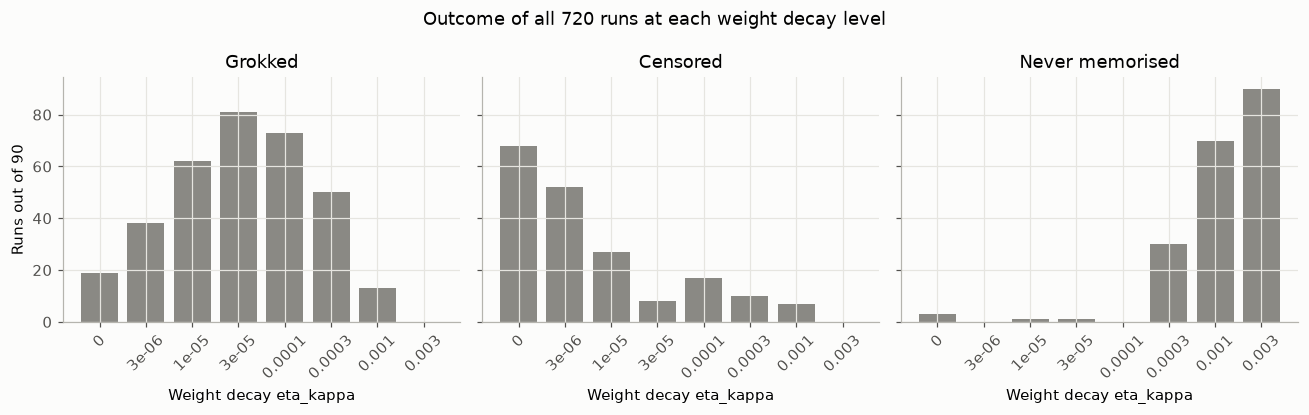

In [7]:
levels = outcome_by_wd.index
level_names = [f'{level:g}' for level in levels]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
for ax, outcome in zip(axes, outcomes):
    ax.bar(level_names, outcome_by_wd[outcome], color=GREY)
    ax.set_title(outcome.capitalize())
    ax.set_xlabel('Weight decay eta_kappa')
    ax.tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Runs out of 90')
fig.suptitle('Outcome of all 720 runs at each weight decay level')
plt.tight_layout()
plt.show()

**What the table and the plot show.**

- The number of grokked runs rises with weight decay up to 3e-5, where 81 of the 90 runs grok. Above 3e-5 it falls again.
- Without weight decay, 68 of the 90 runs are censored. They memorised but did not generalise within 200,000 steps. A small weight decay turns many of these runs into grokked runs.
- From 3e-4 upward, many runs never memorise. At 3e-3 none of the 90 runs memorise.

Now we keep only the runs that grokked and ask how long they took at each level.

In [8]:
grokked = runs[runs['outcome'] == 'grokked']
grokked.groupby('eta_kappa')['t_grok_acc100'].describe()[['count', 'min', '50%', 'max']].round(0)

,count,min,50%,max
eta_kappa,,,,
0.000000,19.0,2021.0,7317.0,66683.0
0.000003,38.0,2021.0,38024.0,197770.0
0.000010,62.0,1520.0,47206.0,173388.0
0.000030,81.0,2517.0,28815.0,173793.0
0.000100,73.0,1676.0,9570.0,151000.0
0.000300,50.0,1191.0,5074.0,18000.0
0.001000,13.0,1308.0,2280.0,4695.0


The column `50%` is the median grokking time. A plot shows the spread better. Each dot is one grokked run, and the black bar is the median of its level. The dots are spread a little sideways so they do not hide each other. The time axis is logarithmic, because the times range from about a thousand steps to about two hundred thousand.

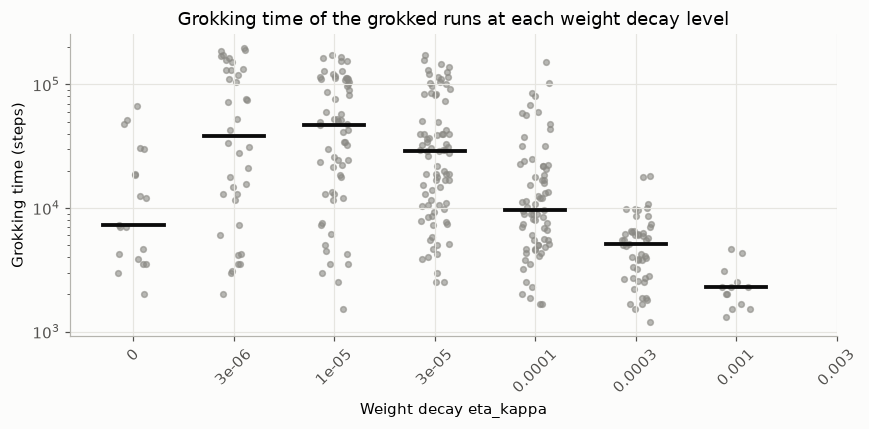

In [9]:
jitter = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(8, 4))
for i, level in enumerate(levels):
    times = grokked.loc[grokked['eta_kappa'] == level, 't_grok_acc100']
    ax.scatter(i + jitter.uniform(-0.15, 0.15, len(times)), times, s=14, color=GREY, alpha=0.6)
    if len(times) > 0:
        ax.plot([i - 0.3, i + 0.3], [times.median()] * 2, color=INK, linewidth=2.5)
ax.set_xticks(range(len(levels)), level_names, rotation=45)
ax.set_yscale('log')
ax.set_xlabel('Weight decay eta_kappa')
ax.set_ylabel('Grokking time (steps)')
ax.set_title('Grokking time of the grokked runs at each weight decay level')
plt.tight_layout()
plt.show()

**What the plot shows.**

- From 1e-5 upward, more weight decay means faster grokking. The median falls from 47,206 steps at 1e-5 to 2,280 steps at 1e-3, a factor of about 20.
- At 3e-6 and 1e-5 many runs take more than 100,000 steps, close to the budget of 200,000.
- The level 0 looks fast, with a median of 7,317 steps. This comes from which runs are left. Without weight decay only 19 runs grokked, and the slow runs are among the 68 censored runs, which have no exact grokking time. Part 3 shows which runs these 19 are.

### Choose two groups

Weight decay changes both the outcome and the grokking time. If we mixed the levels, the weight decay would hide any effect of the kernel. So from here on we hold the weight decay fixed and study two levels, one at a time.

- **Weight decay 3e-5.** This level has the most grokked runs, 81 of its 90, so leaving out the other 9 changes little.
- **No weight decay.** This is the setting of the published baseline that the project reproduces, Kumar et al. (2024), Appendix 8.3 (arXiv:2310.06110v3). Only 19 of its 90 runs grokked, so Part 3 looks at which ones.

`WD_LABEL` and `NO_WD_LABEL` are the names the two groups get in tables and figures.

In [10]:
WD = 3e-5
WD_LABEL = 'weight decay 3e-5'
NO_WD_LABEL = 'no weight decay'

runs_wd = grokked[np.isclose(grokked['eta_kappa'], WD)]
runs_no_wd = grokked[grokked['eta_kappa'] == 0]
len(runs_wd), len(runs_no_wd)

(81, 19)

The dictionary `groups` holds each group under its label, with its colour. The side-by-side figures below loop over it. Its first entry is the group with weight decay, so that group always lands in the left panel. Later parts add more to each entry.

In [11]:
groups = {
    WD_LABEL: {'runs': runs_wd, 'colour': WD_COLOUR},
    NO_WD_LABEL: {'runs': runs_no_wd, 'colour': NO_WD_COLOUR},
}

## Part 3. The two groups side by side

**Runs in this part.** The 81 grokked runs in `runs_wd` on the left, and the 19 grokked runs in `runs_no_wd` on the right.

First we ask where each group groks. Each setting of `alpha` and width has 5 seeds. For each setting we count how many of its seeds grokked.

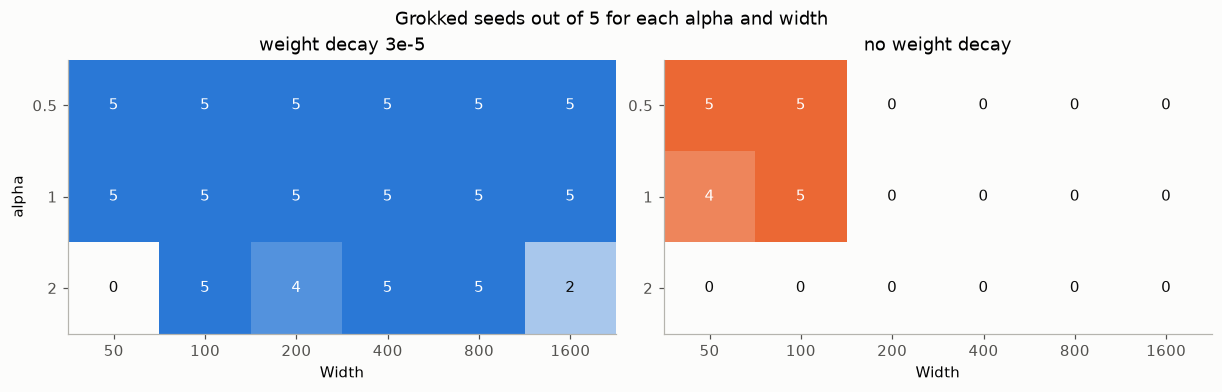

In [12]:
alphas = sorted(runs['alpha'].unique())
widths = sorted(runs['width'].unique())

def grok_counts(group_runs):
    table = pd.crosstab(group_runs['alpha'], group_runs['width'])
    return table.reindex(index=alphas, columns=widths, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), layout='constrained')
for ax, (label, group) in zip(axes, groups.items()):
    counts = grok_counts(group['runs'])
    ramp = LinearSegmentedColormap.from_list(label, [SURFACE, group['colour']])
    ax.imshow(counts, cmap=ramp, vmin=0, vmax=5)
    for i in range(len(alphas)):
        for j in range(len(widths)):
            n = counts.iloc[i, j]
            ax.text(j, i, n, ha='center', va='center', color='white' if n >= 4 else INK)
    ax.set_xticks(range(len(widths)), widths)
    ax.set_yticks(range(len(alphas)), [f'{a:g}' for a in alphas])
    ax.set_xlabel('Width')
    ax.set_title(label)
    ax.grid(False)
axes[0].set_ylabel('alpha')
fig.suptitle('Grokked seeds out of 5 for each alpha and width', y=1.06)
plt.show()

**What the plot shows.**

- With weight decay 3e-5, every setting at `alpha` 0.5 and 1 grokked with all 5 seeds. The 9 missing runs are all at `alpha` 2: all 5 seeds at width 50, one seed at width 200 and three seeds at width 1600.
- Without weight decay, only widths 50 and 100 at `alpha` 0.5 and 1 grokked. No run at `alpha` 2 and no run of width 200 or more grokked.
- So the 81 runs with weight decay cover 17 settings, and the 19 runs without weight decay cover only 4. Every comparison of the two groups below has to keep this in mind.

Next, how long each group takes. Each faint dot is one run. The line joins the median time at each width, with one line per value of `alpha`. Both panels use the same axes, so the right panel shows how few widths are left without weight decay.

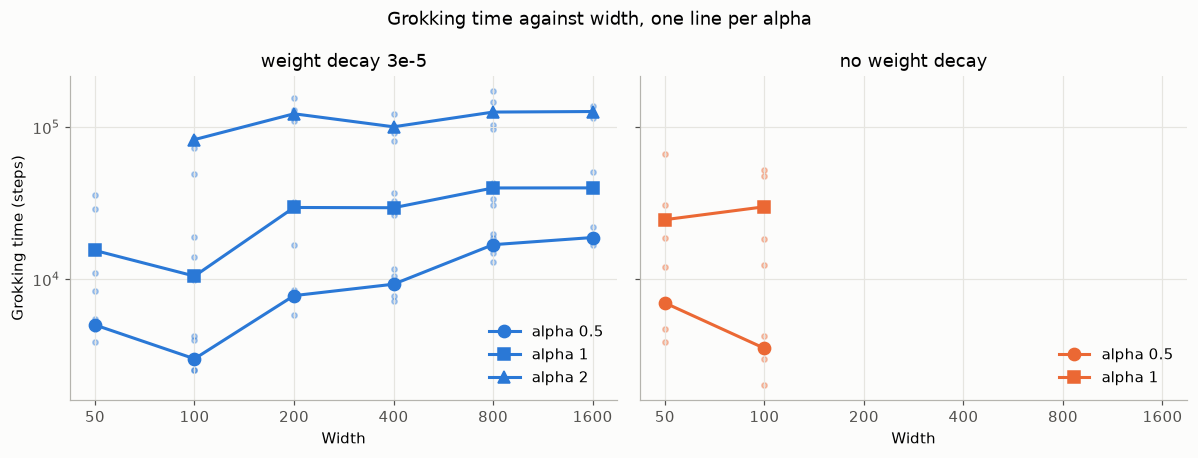

In [13]:
markers = {0.5: 'o', 1.0: 's', 2.0: '^'}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)
for ax, (label, group) in zip(axes, groups.items()):
    for a, marker in markers.items():
        sub = group['runs'][group['runs']['alpha'] == a]
        if len(sub) == 0:
            continue
        ax.scatter(sub['width'], sub['t_grok_acc100'], s=12, color=group['colour'], alpha=0.35)
        medians = sub.groupby('width')['t_grok_acc100'].median()
        ax.plot(medians.index, medians.values, marker=marker, markersize=8,
                color=group['colour'], label=f'alpha {a:g}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks(widths, [str(w) for w in widths])
    ax.minorticks_off()
    ax.set_xlabel('Width')
    ax.set_title(label)
    ax.legend(loc='lower right')
axes[0].set_ylabel('Grokking time (steps)')
fig.suptitle('Grokking time against width, one line per alpha')
plt.tight_layout()
plt.show()

**What the plot shows.**

- With weight decay 3e-5, `alpha` sets most of the grokking time. At every width, `alpha` 2 is the slowest and `alpha` 0.5 is the fastest. The medians run from about 3,000 steps at `alpha` 0.5 and width 100 to about 127,000 steps at `alpha` 2 and width 1600.
- Past width 100, wider networks grok more slowly. From width 100 to width 1600 the median time grows by a factor of about 6 at `alpha` 0.5 and about 4 at `alpha` 1.
- Without weight decay, the right panel is empty past width 100. At `alpha` 0.5 the times run from 2,021 to 7,317 steps. At `alpha` 1 the seeds spread widely, from 12,000 to 66,683 steps.

The two groups share only four settings: `alpha` 0.5 and 1 at widths 50 and 100. To compare the groups fairly we look at those four settings alone. The table gives the median grokking time of each group, and the ratio of the two.

In [14]:
def shared_medians(group_runs):
    shared = group_runs[group_runs['alpha'].isin([0.5, 1.0]) & group_runs['width'].isin([50, 100])]
    return shared.groupby(['alpha', 'width'])['t_grok_acc100'].agg(['count', 'median'])

shared_table = pd.concat({label: shared_medians(group['runs']) for label, group in groups.items()}, axis=1)
shared_table['no wd / wd'] = shared_table[(NO_WD_LABEL, 'median')] / shared_table[(WD_LABEL, 'median')]
shared_table.round(2)

weight decay 3e-5          no weight decay          no wd / wd
                        count   median           count   median           
alpha width                                                               
0.5   50                    5   5014.0               5   7000.0       1.40
      100                   5   3002.0               5   3520.0       1.17
1.0   50                    5  15487.0               4  24678.0       1.59
      100                   5  10504.0               5  30000.0       2.86

On all four shared settings, the runs without weight decay take longer. The ratio runs from 1.17 at `alpha` 0.5 and width 100 to 2.86 at `alpha` 1 and width 100. The setting at `alpha` 1 and width 50 has only 4 grokked runs without weight decay, because one seed was censored. Adding that slow seed could only raise the median, so the gap there may be larger.

So when the settings match, a weight decay of 3e-5 shortens the grokking time. The level 0 looked fast in Part 2 only because its slow runs never grokked.

## Part 4. One run from each group over time

**Runs in this part.** Two runs that differ in weight decay only. Both have `alpha` = 1, width 100 and seed 0.

| Variable | Run | Weight decay | Taken from |
| --- | --- | --- | --- |
| `id_wd` | `ntk_N100_a1_wd3e-05_s0` | 3e-5 | `runs_wd` |
| `id_no_wd` | `ntk_N100_a1_wd0_s0` | none | `runs_no_wd` |

The run without weight decay is the baseline of the project. It uses the settings of Kumar et al. (2024), Appendix 8.3 (arXiv:2310.06110v3): one hidden layer of width 100, learning rate 100, `p` = 23, 90 percent of the pairs for training, and no weight decay. In our runs the learning rate is 100 divided by `alpha` squared, so at `alpha` = 1 it is 100. The group's Tier 0 notebook, `repoduced-code/tier0_reproduction.ipynb`, reproduces this setting over 100,000 steps. Our run is the same setting over 200,000 steps.

Part 3 showed why we use width 100: without weight decay, no run at width 200 or wider grokked.

In [15]:
id_wd = 'ntk_N100_a1_wd3e-05_s0'
id_no_wd = 'ntk_N100_a1_wd0_s0'

events = pd.concat([
    runs_wd[runs_wd['run_id'] == id_wd],
    runs_no_wd[runs_no_wd['run_id'] == id_no_wd],
])[['run_id'] + settings + ['t_mem', 't_gen_acc100', 't_grok_acc100']]
events.index = [WD_LABEL, NO_WD_LABEL]
events

,run_id,alpha,width,eta_kappa,seed,t_mem,t_gen_acc100,t_grok_acc100
weight decay 3e-5,ntk_N100_a1_wd3e-05_s0,1.0,100,0.00003,0,4496.0,15000.0,10504.0
no weight decay,ntk_N100_a1_wd0_s0,1.0,100,0.00000,0,4496.0,17000.0,12504.0


Each row is one run, named by its label. The two runs have the same `alpha`, width and seed, and only `eta_kappa` differs. Both runs memorise at the same checkpoint, step 4,496. The run with weight decay reaches a test accuracy of 1 at step 15,000, and the run without it at step 17,000. So a weight decay of 3e-5 shortens the grokking time here from 12,504 to 10,504 steps, by about 16 percent.

Part 3 found a median ratio of 2.86 at this setting. So seed 0 is a pair in which weight decay helps less than it does for most seeds.

Now we read the checkpoints of each run. The `filters` argument reads just the rows of one run from the large file.

In [16]:
curve_cols = ['step', 'train_acc', 'test_acc', 'A_t', 'S_c', 'R_c']

def read_curves(run_id):
    return pd.read_parquet('data/checkpoints.parquet', columns=curve_cols,
                           filters=[('run_id', '==', run_id)])

curves_wd = read_curves(id_wd)
curves_no_wd = read_curves(id_no_wd)
len(curves_wd), len(curves_no_wd)

(307, 307)

Each run has 307 checkpoints. The dictionary `two_runs` holds what the plots need about each run, under the same labels as `groups`. `mark_events` draws two dotted grey lines in a panel: one where the run memorised and one where it generalised.

In [17]:
two_runs = {
    WD_LABEL: {'curves': curves_wd, 'events': events.loc[WD_LABEL], 'colour': WD_COLOUR},
    NO_WD_LABEL: {'curves': curves_no_wd, 'events': events.loc[NO_WD_LABEL], 'colour': NO_WD_COLOUR},
}

def mark_events(ax, run, names=False):
    for event, name, align in [('t_mem', 'memorised ', 'right'), ('t_gen_acc100', ' generalised', 'left')]:
        ax.axvline(run['events'][event], color=GREY, linestyle=':', linewidth=1.5)
        if names:
            ax.text(run['events'][event], 1.02, name, transform=ax.get_xaxis_transform(),
                    ha=align, va='bottom', fontsize=8, color='#52514e')

First the two accuracies, to see the grokking itself. The dashed line is the train accuracy and the solid line is the test accuracy. The step axis is logarithmic, so step 0 is not shown.

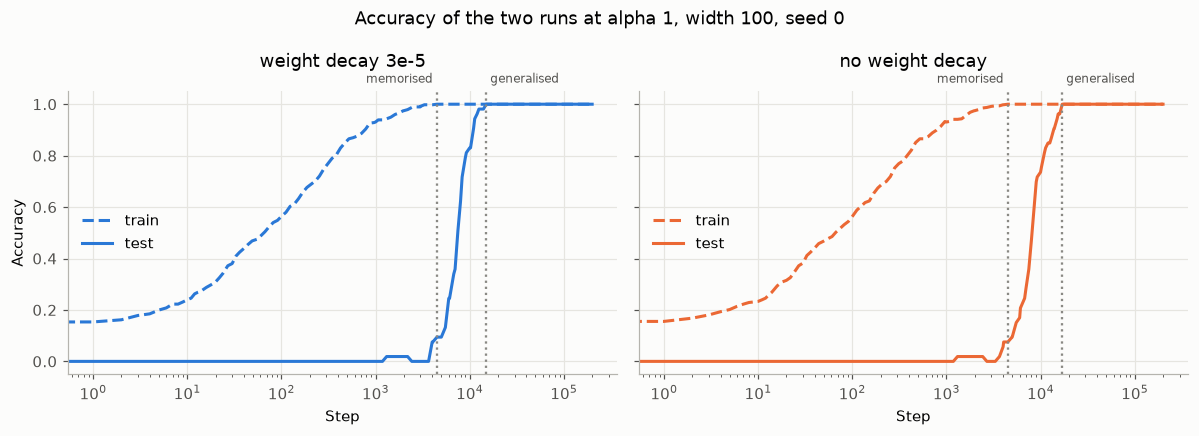

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
for ax, (label, run) in zip(axes, two_runs.items()):
    ax.plot(run['curves']['step'], run['curves']['train_acc'], color=run['colour'],
            linestyle='--', label='train')
    ax.plot(run['curves']['step'], run['curves']['test_acc'], color=run['colour'], label='test')
    mark_events(ax, run, names=True)
    ax.set_xscale('log')
    ax.set_xlabel('Step')
    ax.set_title(label, pad=16)
    ax.legend(loc='center left')
axes[0].set_ylabel('Accuracy')
fig.suptitle('Accuracy of the two runs at alpha 1, width 100, seed 0')
plt.tight_layout()
plt.show()

**What the plot shows.** In both panels the train accuracy climbs to 1 by step 4,496, and the test accuracy stays near 0 until about step 3,000. Then the test accuracy climbs. It reaches 1 at step 15,000 with weight decay and at step 17,000 without it. At this setting the two runs look almost the same.

Now the three kernel numbers. Each row is one number and each column is one run. The panels in a row share their vertical axis, so the two runs can be read against each other. Each panel also shows the other run as a thin grey line, which makes the difference easier to see. `names` maps each data column to the name the report uses, and later parts use it too.

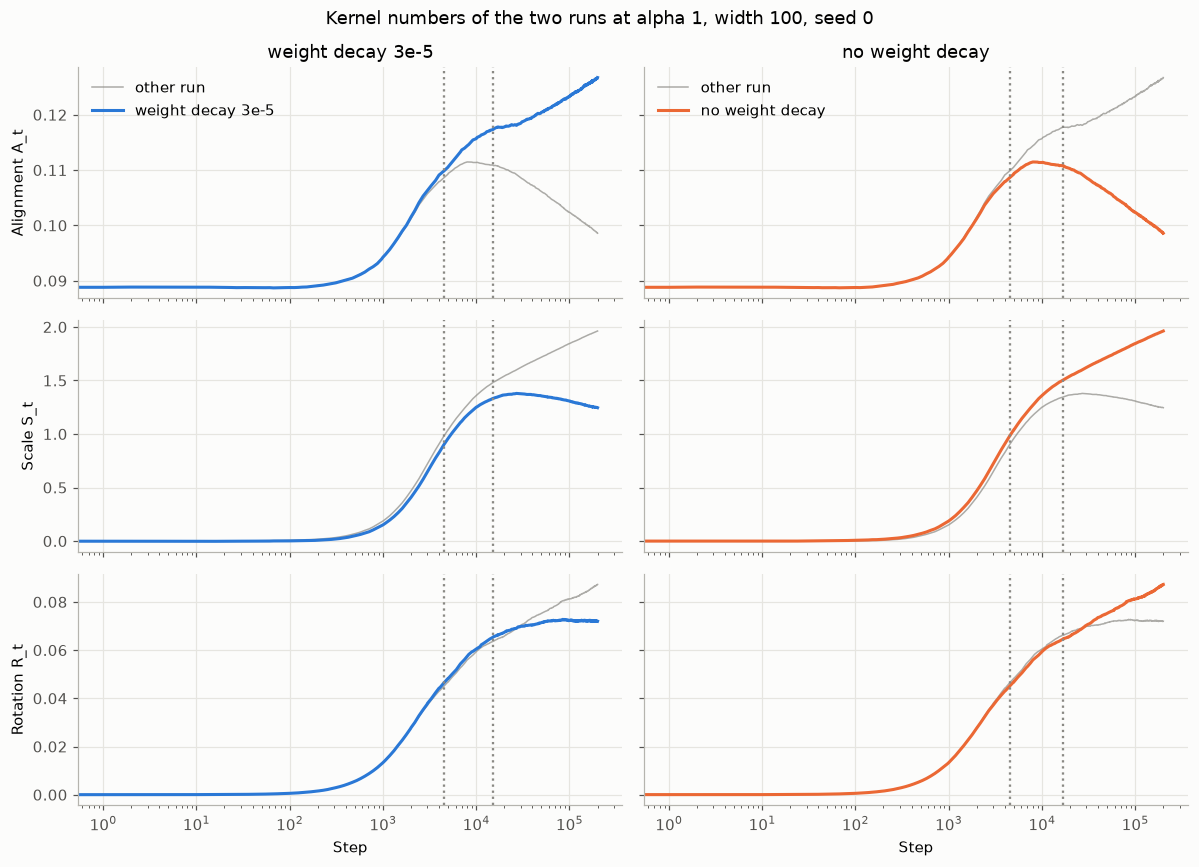

In [19]:
names = {'A_t': 'A_t', 'S_c': 'S_t', 'R_c': 'R_t'}
panels = [('A_t', 'Alignment A_t'), ('S_c', 'Scale S_t'), ('R_c', 'Rotation R_t')]

fig, axes = plt.subplots(3, 2, figsize=(11, 8), sharex=True, sharey='row')
for col_axes, (label, run) in zip(axes.T, two_runs.items()):
    other = [r for l, r in two_runs.items() if l != label][0]
    for ax, (col, name) in zip(col_axes, panels):
        ax.plot(other['curves']['step'], other['curves'][col], color=GREY, linewidth=1,
                alpha=0.7, label='other run')
        ax.plot(run['curves']['step'], run['curves'][col], color=run['colour'], label=label)
        mark_events(ax, run)
    col_axes[0].set_title(label)
    col_axes[0].legend(loc='upper left')
    col_axes[-1].set_xscale('log')
    col_axes[-1].set_xlabel('Step')
for ax, (col, name) in zip(axes[:, 0], panels):
    ax.set_ylabel(name)
fig.suptitle('Kernel numbers of the two runs at alpha 1, width 100, seed 0')
plt.tight_layout()
plt.show()

To read exact values, we print the three numbers at a few steps. The rows are grouped by run, and each column is one step.

In [20]:
steps = [2000, 5000, 10000, 15000, 17000, 30000, 100000, 200000]

def at_steps(curves):
    return curves.set_index('step').loc[steps, ['A_t', 'S_c', 'R_c']].rename(columns=names)

kernel_table = pd.concat({label: at_steps(run['curves']) for label, run in two_runs.items()}, axis=1)
kernel_table.round(3).T

step                   2000    5000    10000   15000   17000   30000   100000  \
weight decay 3e-5 A_t   0.102   0.111   0.116   0.117   0.118   0.118   0.123   
                  S_t   0.408   0.959   1.250   1.331   1.346   1.377   1.309   
                  R_t   0.028   0.048   0.060   0.065   0.066   0.070   0.072   
no weight decay   A_t   0.101   0.109   0.111   0.111   0.111   0.109   0.102   
                  S_t   0.469   1.038   1.359   1.478   1.506   1.621   1.844   
                  R_t   0.028   0.047   0.059   0.064   0.065   0.070   0.081   

step                   200000  
weight decay 3e-5 A_t   0.127  
                  S_t   1.246  
                  R_t   0.072  
no weight decay   A_t   0.099  
                  S_t   1.962  
                  R_t   0.087

**What the plots and the table show.**

- All three numbers start to move a few hundred steps into training, well before the test accuracy climbs. This is why Part 5 can read them early.
- Before generalisation the two runs are close. At step 2,000, `A_t` is 0.102 with weight decay and 0.101 without it, and `R_t` is 0.028 in both. `S_t` grows a little more slowly with weight decay, 0.41 against 0.47.
- **Scale.** Without weight decay, `S_t` keeps rising for the whole run and ends at 1.96. The kernel then ends about 7 times its starting size, since e^1.96 ≈ 7.1. With weight decay, `S_t` peaks at 1.38 near step 27,000 and then falls to 1.25 as the decay shrinks the weights.
- **Alignment.** Without weight decay, `A_t` peaks at 0.111 near step 8,000, before the run generalises. It then falls to 0.099 by the end. With weight decay, `A_t` keeps rising through the whole run, to 0.127.
- **Rotation.** Both runs reach about 0.07 by step 30,000. Without weight decay `R_t` keeps rising, to 0.087. With weight decay it levels off at about 0.072.

In this pair, weight decay moves the grokking time by only 2,000 steps. Its larger effect on the kernel comes after grokking. This is one pair of runs with one seed, so treat it as an example of what can happen.

## Part 5. The grokking step as the report defines it

**Runs in this part.** All 720 runs.

Parts 3 and 4 used the grokking time of the guide: test accuracy 1, measured from memorisation, and only for runs that grokked. From here on we follow the report, Section 3.5.

- The **memorisation step** is the first checkpoint at which the training accuracy reaches 0.99.
- The **grokking step** at level 0.95 is the first checkpoint at which the test accuracy reaches 0.95. It is counted from step 0.
- A run that does not reach a level within the 200,000 steps is **censored**. It is kept, and its time is recorded as 200,000. The model then knows that the true time is longer.

The report uses three levels, 0.80, 0.90 and 0.95. We use 0.95 for the main results, and Part 7 checks the other two. We read the two accuracies at every checkpoint of every run and find the first step that passes each level.

In [21]:
acc = pd.read_parquet('data/checkpoints.parquet', columns=['run_id', 'step', 'train_acc', 'test_acc'])

def first_step(col, level):
    """The first checkpoint of each run at which `col` reaches `level`. Runs that never do are missing."""
    return acc[acc[col] >= level].groupby('run_id')['step'].min()

events = runs[['run_id', 'alpha', 'width', 'eta_kappa', 'seed', 'last_step']].set_index('run_id')
events['t_mem99'] = first_step('train_acc', 0.99)
for level in [0.80, 0.90, 0.95]:
    events[f't_gen{round(level * 100)}'] = first_step('test_acc', level)
events = events.reset_index()
events.head()

,run_id,alpha,width,eta_kappa,seed,last_step,t_mem99,t_gen80,t_gen90,t_gen95
0,ntk_N50_a0.5_wd0_s0,0.5,50,0.0,0,200000,3000.0,4000.0,4496.0,4981.0
1,ntk_N50_a0.5_wd0_s1,0.5,50,0.0,1,200000,3305.0,6776.0,8000.0,8319.0
2,ntk_N50_a0.5_wd0_s2,0.5,50,0.0,2,200000,3305.0,4981.0,5520.0,6776.0
3,ntk_N50_a0.5_wd0_s3,0.5,50,0.0,3,200000,3305.0,5520.0,6000.0,8000.0
4,ntk_N50_a0.5_wd0_s4,0.5,50,0.0,4,200000,2983.0,5520.0,6116.0,6776.0


A missing value means the run never reached that level. Next we set the main target. `T` is the grokking step at 0.95, or the last step for a run that never reached it. `grokked` is 1 when the step was seen and 0 when the run is censored.

In [22]:
LEVEL = 't_gen95'

def set_target(df, level):
    df = df.copy()
    df['grokked'] = df[level].notna().astype(int)
    df['T'] = df[level].fillna(df['last_step'])
    return df

events = set_target(events, LEVEL)
pd.crosstab(events['eta_kappa'], events['grokked'].map({1: 'grokked', 0: 'censored'}))

grokked,censored,grokked
eta_kappa,,
0.000000,67,23
0.000003,50,40
0.000010,26,64
0.000030,4,86
0.000100,13,77
0.000300,40,50
0.001000,75,15
0.003000,90,0


**What the table shows.** At level 0.95, more runs grok than at level 1 in Part 2. Without weight decay, 23 of 90 runs grok, against 19 before. With weight decay 3e-5, 86 grok, against 81. At 3e-3 no run groks, because no run even memorises there.

### A curve that keeps the censored runs

Before fitting any model we look at the times with the **Kaplan-Meier curve** of the report, Equation 9. At each step it gives the share of runs that have not grokked yet. A censored run counts as "not grokked yet" for as long as we watched it, and then leaves the count. So it adds what we know about it and nothing more. The step at which a curve crosses one half is the median grokking step. A curve that stays above one half has no median within the budget.

`KaplanMeierFitter` from lifelines draws the curve. We draw one curve per weight decay level. The two groups of Parts 3 and 4 are in colour and the other levels in grey.

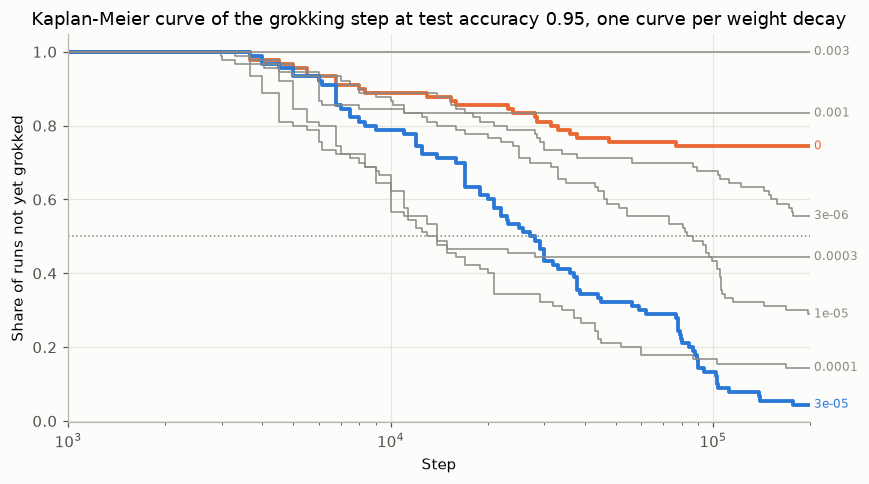

0             NaN
3e-06         NaN
1e-05     83000.0
3e-05     27000.0
0.0001    13000.0
0.0003    13894.0
0.001         NaN
0.003         NaN
Name: median grokking step, dtype: float64

In [23]:
level_colour = {0.0: NO_WD_COLOUR, WD: WD_COLOUR}
fig, ax = plt.subplots(figsize=(8, 4.5))
km_medians = {}
for level, sub in events.groupby('eta_kappa'):
    km = KaplanMeierFitter().fit(sub['T'], sub['grokked'])
    km_medians[f'{level:g}'] = km.median_survival_time_
    colour = next((c for l, c in level_colour.items() if np.isclose(level, l)), GREY)
    km.survival_function_.plot(ax=ax, drawstyle='steps-post', color=colour,
                               linewidth=2.5 if colour != GREY else 1, legend=False)
    ax.text(200_000, km.survival_function_.iloc[-1, 0], f' {level:g}', va='center', fontsize=8, color=colour)
ax.set_xscale('log')
ax.set_xlim(1_000, 200_000)
ax.axhline(0.5, color=GREY, linestyle=':', linewidth=1)
ax.set_xlabel('Step')
ax.set_ylabel('Share of runs not yet grokked')
ax.set_title('Kaplan-Meier curve of the grokking step at test accuracy 0.95, one curve per weight decay')
plt.tight_layout()
plt.show()
pd.Series(km_medians, name='median grokking step').replace(np.inf, np.nan)

**What the curve shows.**

- No run groks before step 2,983. Every curve stays at 1 until then.
- Weight decay 1e-4 and 3e-4 reach their medians first, near step 13,000. Weight decay 3e-5 reaches its median later, at step 27,000, but it ends lowest: by the budget only 4 of its 90 runs have not grokked.
- The curve at 3e-4 falls early and then stays flat near 0.44. Runs at this level grok fast when they grok at all, and many of the others never memorise. The curve at 1e-3 stops even higher.
- Without weight decay, and at 3e-6 and 1e-3, the curve stays above one half. Those levels have no median within the budget.

The curves cross. The curve at 3e-5 starts above the curve at 1e-4 and ends below it. So weight decay does not shift every run by the same factor, and a model of the grokking time has to let each level have its own effect. Part 7 does this.

## Part 6. What a model may read, and when

**Runs in this part.** All runs up to weight decay 1e-3. The level 3e-3 is left out, because none of its runs memorise and it has nothing to teach a model.

A model that predicts grokking must use only what is known before the run groks. Otherwise it reads the answer. This is called **lookahead**. This part fixes the moment at which the inputs are read, and checks that it comes before every event.

### The landmark

We read the kernel at one fixed step for every run, called the **landmark**. A model fitted on numbers read at the landmark makes a prediction that could be made at that step. We fix the landmark at step 2,000, and we check that no run has grokked by then, at any of the three levels.

In [24]:
LANDMARK = 2_000
earliest = events[['t_gen80', 't_gen90', 't_gen95']].min()
assert (earliest > LANDMARK).all(), 'a run grokked before the landmark'
test_acc_at_landmark = acc.loc[acc['step'] == LANDMARK, 'test_acc']
pd.Series({**{f'earliest {c}': v for c, v in earliest.items()},
           'largest test accuracy at the landmark': test_acc_at_landmark.max()}).round(3)

earliest t_gen80                         2983.00
earliest t_gen90                         2983.00
earliest t_gen95                         2983.00
largest test accuracy at the landmark       0.17
dtype: float64

The earliest run reaches a test accuracy of 0.80 at step 2,983. At step 2,000 the largest test accuracy of any run is 0.17. So no run has grokked at the landmark, and the kernel there does not contain the answer.

### Why we count from step 0 and not from memorisation

Parts 1 to 4 measured the grokking time from memorisation. The table below shows why that does not fit a landmark: many runs have memorised before step 2,000.

In [25]:
pd.Series({'runs that memorised by the landmark': (events['t_mem99'] <= LANDMARK).sum(),
           'earliest memorisation step': events['t_mem99'].min(),
           'runs': len(events)})

runs that memorised by the landmark    349.0
earliest memorisation step              49.0
runs                                   720.0
dtype: float64

About half the runs have memorised by step 2,000, some as early as step 49. For those runs, a gap measured from memorisation has already started when the kernel is read. For the others it has not. The same input would then be read at a different point of the interval it predicts. Counting from step 0 puts every run in the same position: none has grokked, and all are still being watched.

### Columns that a model must never read

`runs.parquet` holds some columns that are measured at the grokking step or at the end of a run. They are fine for describing a run and must never be inputs. We list them here so that a later cell can check that no input comes from this list.

In [26]:
after_the_event = [c for c in runs.columns
                   if c.endswith(('_at_gen', '_final')) or c.startswith(('A_peak', 't_A'))
                   or c in ['weight_norm_growth', 'final_weight_norm']]
after_the_event

['final_weight_norm',
 'weight_norm_growth',
 'A_t_final',
 'A_full_final',
 'S_c_final',
 'R_c_final',
 'train_acc_final',
 'test_acc_final',
 'train_loss_final',
 'test_loss_final',
 'A_peak',
 'A_peak_step',
 'A_t_at_gen',
 'S_c_at_gen',
 'R_c_at_gen',
 'gamma_at_gen',
 'D_at_gen',
 'weight_norm_at_gen',
 'A_full_at_gen',
 'S_W1_at_gen',
 'S_W2_at_gen',
 't_A08',
 't_A10',
 't_A12',
 't_A14']

### Near twins and the unit of the analysis

The 5 seeds of one setting of `alpha`, width and weight decay are near twins. We call one setting a **cell**. The table below takes the runs at weight decay 3e-5 that grokked and asks how much of the spread in their log grokking step lies between cells and how much lies between the seeds inside a cell.

In [27]:
events['cell'] = (events['alpha'].astype(str) + '_' + events['width'].astype(str) + '_'
                  + events['eta_kappa'].map('{:g}'.format))
seen_wd = events[np.isclose(events['eta_kappa'], WD) & (events['grokked'] == 1)]
log_T = np.log10(seen_wd['T'])
between = log_T.groupby(seen_wd['cell']).transform('mean').var() / log_T.var()
pd.Series({'cells': seen_wd['cell'].nunique(), 'runs': len(seen_wd),
           'share of the spread between cells': round(between, 3)})

cells                                18.000
runs                                 86.000
share of the spread between cells     0.981
dtype: float64

Almost all of the spread lies between cells. The seeds of a cell differ little. So these runs hold the information of about 17 cells, not 86 independent runs.

This has two consequences for the rest of the notebook.

1. A model is always scored on cells it has not seen. `LeaveOneGroupOut` leaves out one cell at a time, fits on all the others, and predicts the left-out cell. Every run then gets one prediction from a model that never saw any of its twins. Parts 7 and 8 of the earlier version split runs at random, and their scores were too high for this reason.
2. More seeds would add little. More cells add a lot. So Part 7 also pools every weight decay level up to 1e-3, which gives 126 cells.

### The data for Parts 7 and 8

We read the kernel at the landmark and join it to the events. `inputs` holds the three kernel columns. The dictionary `sets` holds the three sets of runs that Parts 7 and 8 use, each with its colour.

In [28]:
inputs = ['A_t', 'S_c', 'R_c']
assert not set(inputs) & set(after_the_event)
at_landmark = pd.read_parquet('data/checkpoints.parquet', columns=['run_id'] + inputs,
                              filters=[('step', '==', LANDMARK)])
data = events.merge(at_landmark, on='run_id')
data = data[data['eta_kappa'] <= 1e-3].reset_index(drop=True)

POOLED_LABEL = 'all levels up to 1e-3'
sets = {
    WD_LABEL: {'data': data[np.isclose(data['eta_kappa'], WD)].reset_index(drop=True), 'colour': WD_COLOUR},
    NO_WD_LABEL: {'data': data[data['eta_kappa'] == 0].reset_index(drop=True), 'colour': NO_WD_COLOUR},
    POOLED_LABEL: {'data': data, 'colour': POOLED_COLOUR},
}
pd.DataFrame({label: {'runs': len(s['data']), 'cells': s['data']['cell'].nunique(),
                      'grokked': s['data']['grokked'].sum()} for label, s in sets.items()}).T

,runs,cells,grokked
weight decay 3e-5,90,18,86
no weight decay,90,18,23
all levels up to 1e-3,630,126,355


## Part 7. Does the kernel predict the grokking step beyond the settings?

**Runs in this part.** The three sets in `sets`: weight decay 3e-5, no weight decay, and all levels up to 1e-3 pooled.

### A straight line that allows censored runs

The earlier version fitted a straight line to the log grokking time of the runs that grokked. The **log-normal accelerated failure time model** of the report, Equation 10, is the same straight line with one change. It reads

`log T = intercept + b_1 * x_1 + b_2 * x_2 + ... + noise`,

where the noise has a normal distribution. A run that grokked adds the chance of its exact time, as in least squares. A censored run adds the chance that its time is longer than the budget (Equation 11). So the censored runs stay in the fit and pull the line toward longer times where they belong. A negative coefficient means a shorter grokking step. `LogNormalAFTFitter` from lifelines fits it.

We compare three sets of inputs.

- **settings**: one indicator for each value of `alpha`, of width and of weight decay. An indicator lets each value have its own effect, which the crossing curves of Part 5 need.
- **kernel**: the three kernel numbers at the landmark, standardised.
- **settings + kernel**: both.

If the kernel tells us something the settings do not, the third model should beat the first on cells it has not seen.

`design` builds the inputs. It standardises the kernel numbers with the mean and standard deviation of the training runs only. A small penalty, 0.01, keeps the coefficients finite when a value of a setting has no grokked run at all, as `alpha` 2 without weight decay. The model counts time from step 0. Part 6 checked that no run groks before the landmark, so every run in the fit is still waiting to grok when its inputs are read.

In [29]:
def design(df, cols, use_settings, ref):
    """Inputs for the rows of `df`, with every scale taken from the training rows `ref`."""
    X = pd.DataFrame(index=df.index)
    if use_settings:
        for setting in ['alpha', 'width', 'eta_kappa']:
            for value in sorted(ref[setting].unique())[1:]:
                X[f'{setting}={value:g}'] = (df[setting] == value).astype(float)
    for col in cols:
        X[names.get(col, col)] = (df[col] - ref[col].mean()) / ref[col].std()
    return X

def fit_aft(df, cols, use_settings, ref=None):
    ref = df if ref is None else ref
    table = design(df, cols, use_settings, ref).assign(T=df['T'], grokked=df['grokked'])
    return LogNormalAFTFitter(penalizer=0.01).fit(table, 'T', 'grokked')

MODELS = {'settings': ([], True), 'kernel': (inputs, False), 'settings + kernel': (inputs, True)}

### Scoring on cells the model has not seen

A censored run has no exact time, so R squared cannot score these models. The usual score is the **concordance index**. Take every pair of runs where we know which one grokked first. The index is the share of those pairs that the model puts in the right order. 0.5 is a coin toss and 1 is a perfect order. It plays the role that R squared played before.

`held_out_medians` leaves out one cell at a time, fits on the rest, and predicts the median grokking step of the left-out runs. The pooled set needs 126 fits per model, so this cell takes about a minute.

In [30]:
def held_out_medians(df, cols, use_settings):
    pred = pd.Series(index=df.index, dtype=float)
    for train, test in LeaveOneGroupOut().split(df, groups=df['cell']):
        tr, te = df.iloc[train], df.iloc[test]
        model = fit_aft(tr, cols, use_settings)
        pred.iloc[test] = model.predict_median(design(te, cols, use_settings, tr)).to_numpy().ravel()
    return pred

concordance = pd.DataFrame({
    label: {name: concordance_index(s['data']['T'], held_out_medians(s['data'], cols, use), s['data']['grokked'])
            for name, (cols, use) in MODELS.items()}
    for label, s in sets.items()
})
concordance.round(3)

,weight decay 3e-5,no weight decay,all levels up to 1e-3
settings,0.891,0.974,0.877
kernel,0.874,0.914,0.841
settings + kernel,0.940,0.968,0.901


**What the table shows.**

- The settings alone order the runs well in every set. Their concordance is 0.891 with weight decay 3e-5, 0.974 without weight decay and 0.877 pooled.
- The kernel alone does a little worse than the settings in every set, at 0.874, 0.914 and 0.841.
- Adding the kernel to the settings helps with weight decay 3e-5, from 0.891 to 0.940, and in the pooled set, from 0.877 to 0.901. Without weight decay it does not help, 0.974 against 0.968. In that set only 5 of the 18 cells have a grokked run, and the settings already order nearly every pair.

This differs from the earlier version of Part 7, which found that the kernel added nothing to the settings. That version dropped the censored runs and split seeds of one cell across the training and test sets. With every run kept and whole cells held out, the kernel at step 2,000 does carry information that the settings do not.

### Which kernel numbers matter? The fitted coefficients

Now we fit the settings + kernel model on every run of each set and read its three kernel coefficients. The model works in natural log steps. A coefficient of -0.1 means a grokking step about 10 percent shorter for one standard deviation more of that input.

The **likelihood ratio test** asks whether the three kernel numbers together improve the fit of the settings model. It compares the log likelihood of the two fits. Twice the gain has a chi-squared distribution with 3 degrees of freedom when the kernel adds nothing. The penalty makes this test approximate.

Part 5 of the earlier version found that `A_t` and `S_t` have a correlation of about 0.95. One coefficient of the pair is then poorly determined, and the joint test is the safer answer to "does the kernel matter".

In [31]:
def kernel_coefficients(s):
    full = fit_aft(s['data'], inputs, True)
    base = fit_aft(s['data'], [], True)
    lr = 2 * (full.log_likelihood_ - base.log_likelihood_)
    summary = full.summary.loc['mu_'].loc[list(names.values()), ['coef', 'coef lower 95%', 'coef upper 95%', 'p']]
    return summary, chi2.sf(lr, df=3)

aft_fits = {label: kernel_coefficients(s) for label, s in sets.items()}
pd.concat({label: fit[0] for label, fit in aft_fits.items()}).round(3)

coef  coef lower 95%  coef upper 95%      p
                      covariate                                              
weight decay 3e-5     A_t       -0.327          -0.510          -0.143  0.000
                      S_t        0.135          -0.081           0.350  0.221
                      R_t       -0.282          -0.397          -0.166  0.000
no weight decay       A_t       -0.298          -0.961           0.366  0.379
                      S_t       -0.869          -1.946           0.208  0.114
                      R_t       -0.058          -0.635           0.518  0.842
all levels up to 1e-3 A_t       -0.998          -1.232          -0.763  0.000
                      S_t        0.443           0.122           0.764  0.007
                      R_t       -0.107          -0.288           0.075  0.250

In [32]:
pd.Series({label: fit[1] for label, fit in aft_fits.items()}, name='likelihood ratio test p').map('{:.2g}'.format)

weight decay 3e-5        1.8e-20
no weight decay             0.04
all levels up to 1e-3    9.3e-25
Name: likelihood ratio test p, dtype: str

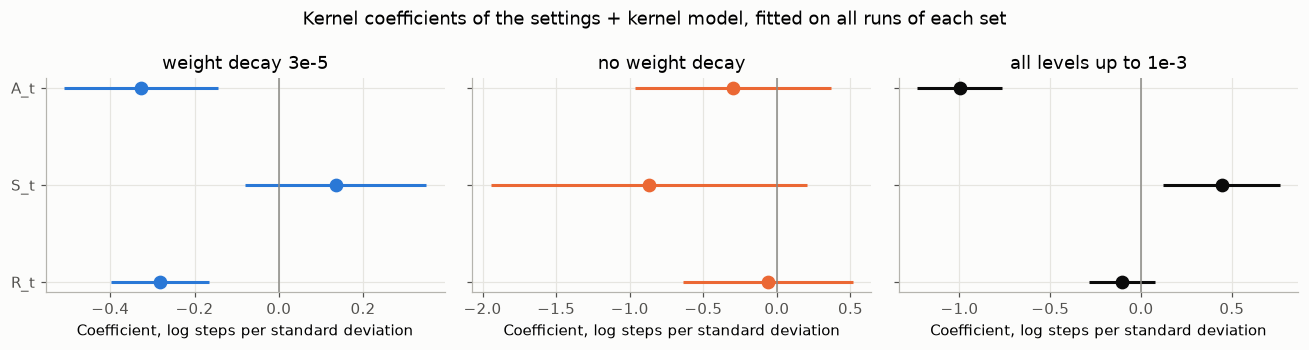

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, (label, (summary, p)) in zip(axes, aft_fits.items()):
    y = np.arange(len(summary))
    ax.errorbar(summary['coef'], y, xerr=[summary['coef'] - summary['coef lower 95%'],
                                          summary['coef upper 95%'] - summary['coef']],
                fmt='o', markersize=8, color=sets[label]['colour'], linewidth=2)
    ax.axvline(0, color=GREY, linewidth=1)
    ax.set_yticks(y, summary.index)
    ax.set_xlabel('Coefficient, log steps per standard deviation')
    ax.set_title(label)
axes[0].invert_yaxis()
fig.suptitle('Kernel coefficients of the settings + kernel model, fitted on all runs of each set')
plt.tight_layout()
plt.show()

**What the coefficients show.**

- With weight decay 3e-5, `A_t` and `R_t` both have negative coefficients whose intervals exclude 0: -0.33 and -0.28. One standard deviation more of `A_t` goes with a grokking step about 28 percent shorter, since e^-0.33 is about 0.72. `S_t` has an interval that includes 0.
- Without weight decay, every interval includes 0. The joint test gives p = 0.04, so the three numbers together add a little, and the data cannot say which one.
- In the pooled set, `A_t` has the largest coefficient, -1.0. One standard deviation more of `A_t` goes with a grokking step about 63 percent shorter. `S_t` has a positive coefficient, +0.44, and `R_t` has an interval that includes 0.
- The joint tests give p = 2e-20 with weight decay 3e-5 and p = 9e-25 pooled.

The positive sign of `S_t` in the pooled set does not mean that a larger kernel slows grokking. `S_t` and `A_t` move together, and the model gives `S_t` the part that is left once `A_t` is in. Read the two as a pair. The pair says that a kernel that has moved further toward the labels by step 2,000 goes with an earlier grokking step.

These intervals treat the 5 seeds of a cell as independent runs, so they are too narrow. The next test does not have this problem.

### Inside a cell: do seeds with a more moved kernel grok sooner?

The settings explain almost all the spread between cells. A sharper question is whether the kernel explains the spread between the seeds of one cell. For this we use a **Cox model**, the other model the report uses (Equations 13 and 14).

A Cox model does not predict a time. It predicts the **hazard**, the chance that a run groks at the next step given that it has not grokked yet. Each input multiplies the hazard by a factor. A positive coefficient means a higher hazard, so an earlier grokking step. That is the opposite sign of the accelerated failure time model.

We fit it with one **stratum** per cell. Each cell then gets its own baseline hazard, and the model only compares runs inside the same cell. The settings drop out entirely, and what is left is the effect of the kernel among near twins. Cells in which no seed groks add nothing to the fit.

In [34]:
def within_cell_cox(df):
    table = df[['T', 'grokked', 'cell']].join(design(df, inputs, False, df))
    model = CoxPHFitter().fit(table, 'T', 'grokked', strata='cell', robust=True)
    return model.summary[['coef', 'p']], model.log_likelihood_ratio_test().p_value

within = {label: within_cell_cox(s['data']) for label, s in sets.items()}
table = pd.concat({label: fit[0] for label, fit in within.items()}).unstack()
table['joint p'] = [within[label][1] for label in table.index]
table.round(3)

coef                    p               joint p
covariate                A_t    S_t    R_t    A_t    S_t    R_t        
weight decay 3e-5      2.103 -6.506 -0.501  0.010  0.145  0.707   0.122
no weight decay        2.138  1.308 -1.253  0.006  0.764  0.611   0.105
all levels up to 1e-3  1.602  0.934 -1.026  0.000  0.736  0.181   0.000

**What the table shows.**

- In all three sets, `A_t` has a positive coefficient whose p-value is below 0.05: 2.1 with weight decay 3e-5, 2.1 without weight decay and 1.6 pooled. A positive coefficient means a higher hazard. So among the seeds of one cell, the seed with the higher alignment at step 2,000 tends to grok first.
- Within one weight decay level, the joint test of all three numbers does not reach 0.05. Its p-values are 0.12 and 0.10. The 18 cells of one level are too few to test three numbers at once.
- Pooled over 126 cells, the joint test gives p below 0.001.

The coefficients are per standard deviation across all runs. The seeds of one cell differ by a small part of that, so the sizes look large. The large negative `S_t` coefficient with weight decay 3e-5, -6.5, comes from the same pairing of `A_t` and `S_t` as above, and its p-value is 0.15. Read the signs and the p-values, and not the sizes.

This is the cleanest answer to "does the kernel predict grokking beyond the settings". The settings drop out completely. The standard errors are the robust ones, which do not rely on the model being exactly right.

### The report's model: the kernel at every checkpoint

The landmark reads the kernel once. The report's Equation 13 lets the kernel change along the run, and asks whether the current kernel goes with the hazard of grokking at the next step. lifelines fits this with `CoxTimeVaryingFitter`. It needs the data in a long form: one row per run and per stretch between two checkpoints, with the inputs as they were at the start of the stretch.

Holding the inputs at their value from the start of each stretch is what keeps this model free of lookahead. A run that groks at checkpoint t is recorded in the stretch that ends at t, and the inputs of that stretch come from the checkpoint before t. The report calls this left-continuous.

We start the stretches at the landmark, since no run groks before it. Each input is standardised with the mean and standard deviation across runs at the landmark, so one unit means the same as in the models above. The model is stratified by cell, as before.

`long_form` reads the checkpoints for the inputs we ask for, and builds the stretches for one grokking level.

In [35]:
def long_form(cols, level):
    ck = pd.read_parquet('data/checkpoints.parquet', columns=['run_id', 'step'] + cols)
    ev = set_target(events, level)
    ck = ck.merge(ev[['run_id', 'T', 'grokked', 'cell', 'eta_kappa']], on='run_id')
    ck = ck[ck['eta_kappa'] <= 1e-3].sort_values(['run_id', 'step'])
    ck['stop'] = ck.groupby('run_id')['step'].shift(-1)
    ck = ck.rename(columns={'step': 'start'}).dropna(subset=['stop'])
    ck = ck[(ck['start'] >= LANDMARK) & (ck['start'] < ck['T'])]
    ck['event'] = ((ck['stop'] == ck['T']) & (ck['grokked'] == 1)).astype(int)
    assert ck['event'].sum() == ev.loc[ev['eta_kappa'] <= 1e-3, 'grokked'].sum()
    ref = ck[ck['start'] == LANDMARK]
    for col in cols:
        ck[col] = (ck[col] - ref[col].mean()) / ref[col].std()
    return ck

def time_varying_cox(long, cols):
    model = CoxTimeVaryingFitter().fit(long[['run_id', 'start', 'stop', 'event', 'cell'] + cols],
                                       id_col='run_id', event_col='event', start_col='start',
                                       stop_col='stop', strata='cell')
    return model.summary[['coef', 'p']], model.log_likelihood_ratio_test().p_value

long = long_form(inputs, LEVEL)
subsets = {WD_LABEL: np.isclose(long['eta_kappa'], WD), NO_WD_LABEL: long['eta_kappa'] == 0,
           POOLED_LABEL: np.ones(len(long), bool)}
varying = {label: time_varying_cox(long[mask], inputs) for label, mask in subsets.items()}
table = pd.concat({label: fit[0].rename(index=names) for label, fit in varying.items()}).unstack()
table['joint p'] = [varying[label][1] for label in table.index]
table.round(3)

coef                     p               joint p
covariate                A_t     S_t    R_t    A_t    S_t    R_t        
weight decay 3e-5      4.131   4.832  1.917  0.001  0.164  0.154   0.001
no weight decay        9.468  11.211 -2.563  0.007  0.015  0.132   0.001
all levels up to 1e-3  3.469   4.549 -0.012  0.000  0.000  0.983   0.000

**What the table shows.**

- In all three sets the joint test gives p of 0.001 or below.
- `A_t` and `S_t` have positive coefficients. At any step, among the runs of one cell that have not grokked yet, a run with a higher current alignment and a larger kernel tends to grok sooner.
- `R_t` adds nothing once the other two are in. Its p-values are 0.15, 0.13 and 0.98.

This model reads the kernel up to the checkpoint just before each event, which is up to 1,000 steps earlier. So it shows that the kernel moves along with the approach of grokking, which is a description of the run. It is not an early warning. The landmark models above are the early warnings. The report also notes, in Section 3.5, that these inputs are internal: the run that groks also produces them. So the model says nothing about what causes what.

The assert in `long_form` checks that every grokked run has exactly one event row. lifelines does not yet offer robust standard errors for this model, so these p-values assume that the stretches of one run are independent given the inputs.

### Does the answer depend on our choices?

We repeat the pooled time-varying model for every grokking level of the report, and for the kernel measured on three parts of the probe.

- **whole probe**: `A_t`, `S_c`, `R_c`, as above.
- **test pairs**: `A_t_test`, `S_c_test`, `R_c_test`. This is the set of pairs on which the report measures its statistics.
- **training pairs**: `A_t_train`, `S_c_train`, `R_c_train`. Their alignment uses only the labels of training pairs, so it uses nothing a practitioner would not have.

In [36]:
probe_parts = {'whole probe': inputs,
               'test pairs': ['A_t_test', 'S_c_test', 'R_c_test'],
               'training pairs': ['A_t_train', 'S_c_train', 'R_c_train']}
rows = {}
for part, cols in probe_parts.items():
    for level in ['t_gen80', 't_gen90', 't_gen95']:
        summary, p = time_varying_cox(long_form(cols, level), cols)
        rows[(part, level)] = {**dict(zip(['A', 'S', 'R'], summary['coef'])), 'joint p': p}
robust_table = pd.DataFrame.from_dict(rows, orient='index')
robust_table.index.names = ['kernel on', 'level']
robust_table.round(3)

A      S      R  joint p
kernel on      level                                
whole probe    t_gen80  3.533  5.912  0.779    0.000
               t_gen90  3.786  4.270  0.524    0.000
               t_gen95  3.469  4.549 -0.012    0.000
test pairs     t_gen80 -0.383  7.726 -0.896    0.000
               t_gen90 -0.420  4.053 -1.152    0.000
               t_gen95 -0.203  2.303 -0.984    0.005
training pairs t_gen80  3.346  5.782  1.454    0.000
               t_gen90  3.561  3.978  1.198    0.000
               t_gen95  3.284  4.243  0.450    0.000

**What the table shows.**

- The three grokking levels give the same picture. The joint test has p of 0.005 or below in every row.
- The kernel on the training pairs gives the same coefficients as the kernel on the whole probe. So the signal in `A_t` does not come from the labels of the test pairs.
- On the 53 test pairs alone, the alignment carries no signal. Its coefficient is near 0, from -0.4 to -0.2. The scale carries it instead. This matters for the report, whose Equation 6 measures all its numbers on the test pairs. On those pairs alone, the alignment would look unrelated to the grokking step.

## Part 8. Will a run grok within the budget?

**Runs in this part.** The runs without weight decay, and all levels up to 1e-3 pooled. The runs with weight decay 3e-5 are left out, for the reason in the next cell.

The target is `grokked`: 1 if the run reached a test accuracy of 0.95 within the budget. A logistic regression predicts it from the same three sets of inputs as Part 7, and it is scored on cells it has not seen.

In [37]:
pd.DataFrame({label: s['data'].groupby('grokked')['cell'].agg(['size', 'nunique']).stack()
              for label, s in sets.items()}).fillna(0).astype(int)

weight decay 3e-5  no weight decay  all levels up to 1e-3
grokked                                                                   
0       size                     4               67                    275
        nunique                  1               14                     57
1       size                    86               23                    355
        nunique                 18                5                     75

With weight decay 3e-5, only 4 runs do not grok, and all 4 sit in one cell, `alpha` 2 and width 50. When that cell is held out, the training runs hold only grokked runs and the model cannot learn the other class. So that set cannot answer this question.

### Scores that see both classes

Accuracy can look high when one class is large. Two scores avoid this.

- **Balanced accuracy** is the mean of the share right among grokked runs and the share right among the others. Always guessing one class gives 0.5.
- **AUC** is the chance that a random grokked run gets a higher predicted probability than a random run that did not grok. 0.5 is a coin toss and 1 is perfect. It does not depend on the cut at 0.5.

`held_out_probabilities` is the logistic version of `held_out_medians`.

In [38]:
def held_out_probabilities(df, cols, use_settings):
    prob = pd.Series(index=df.index, dtype=float)
    for train, test in LeaveOneGroupOut().split(df, groups=df['cell']):
        tr, te = df.iloc[train], df.iloc[test]
        model = LogisticRegression(max_iter=1000).fit(design(tr, cols, use_settings, tr), tr['grokked'])
        prob.iloc[test] = model.predict_proba(design(te, cols, use_settings, tr))[:, 1]
    return prob

def class_scores(y, prob):
    return {'AUC': roc_auc_score(y, prob), 'balanced accuracy': balanced_accuracy_score(y, prob > 0.5),
            'accuracy': accuracy_score(y, prob > 0.5)}

logistic_sets = {label: sets[label] for label in [NO_WD_LABEL, POOLED_LABEL]}
logistic_scores = pd.DataFrame.from_dict({
    (label, name): class_scores(s['data']['grokked'], held_out_probabilities(s['data'], cols, use))
    for label, s in logistic_sets.items() for name, (cols, use) in MODELS.items()
}, orient='index')
share_grokked = {label: s['data']['grokked'].mean() for label, s in logistic_sets.items()}
logistic_scores['always guess the larger class'] = [
    max(share_grokked[label], 1 - share_grokked[label]) for label, _ in logistic_scores.index]
logistic_scores.round(3)

AUC  balanced accuracy  accuracy  \
no weight decay       settings           0.855              0.680     0.800   
                      kernel             0.969              0.876     0.922   
                      settings + kernel  0.992              0.826     0.911   
all levels up to 1e-3 settings           0.950              0.864     0.867   
                      kernel             0.880              0.808     0.805   
                      settings + kernel  0.965              0.888     0.890   

                                         always guess the larger class  
no weight decay       settings                                   0.744  
                      kernel                                     0.744  
                      settings + kernel                          0.744  
all levels up to 1e-3 settings                                   0.563  
                      kernel                                     0.563  
                      settings + kernel                          0.563

**What the table shows.**

- Without weight decay, the kernel predicts better than the settings: an AUC of 0.969 against 0.855, and a balanced accuracy of 0.876 against 0.680. The settings model adds one effect for each value of `alpha` and one for each width. Without weight decay, runs grok only where a small width meets a small `alpha`. A held-out cell of that kind is hard to place from the effects alone. The kernel at step 2,000 already shows it.
- Pooled, the settings do well on their own, with an AUC of 0.950. Adding the kernel raises it to 0.965 and the balanced accuracy from 0.864 to 0.888.
- Every model beats always guessing the larger class, which gives accuracies of 0.744 and 0.563.

The earlier version of Part 8 found that the kernel added nothing without weight decay. It used the level of 1 instead of 0.95, numbers instead of indicators for the settings, and folds of five. With 5 grokked cells out of 18, such choices move the answer. Treat the pooled result as the main one.

### Which kernel number does the classifier lean on?

We drop one kernel number at a time from the pooled settings + kernel model and score it again on held-out cells. A number whose removal costs the most carries information the other two do not. Because `A_t` and `S_t` move together, dropping one of them can cost little even when the pair matters.

In [39]:
pooled = sets[POOLED_LABEL]['data']
drops = {'none': inputs, **{f'drop {names[c]}': [k for k in inputs if k != c] for c in inputs}}
pd.DataFrame({name: class_scores(pooled['grokked'], held_out_probabilities(pooled, cols, True))
              for name, cols in drops.items()}).T.round(3)

,AUC,balanced accuracy,accuracy
none,0.965,0.888,0.890
drop A_t,0.960,0.882,0.881
drop S_t,0.964,0.893,0.894
drop R_t,0.958,0.864,0.867


**What the table shows.** Dropping `R_t` costs the most. The balanced accuracy falls from 0.888 to 0.864 and the AUC from 0.965 to 0.958. Dropping `A_t` costs a little, and dropping `S_t` costs nothing. So for whether a run groks at all, the rotation carries information that the other two do not. For when a run groks, Part 7 found the reverse: the alignment carried the signal and the rotation added little once the others were in.

## Summary

### Parts 1 and 2: all 720 runs

- The sweep ran every mix of 3 values of `alpha`, 6 widths, 8 weight decay levels and 5 seeds. 336 runs grokked at test accuracy 1, 189 were censored and 195 never memorised.
- Weight decay sets the outcome. Without it most runs are censored. From 3e-4 upward many runs never memorise. At 3e-5, 81 of the 90 runs grok.

### Part 3: the two groups side by side

- With weight decay 3e-5, runs grok at every width. `alpha` sets most of the grokking time, and past width 100 wider networks grok more slowly.
- Without weight decay, only widths 50 and 100 at `alpha` 0.5 and 1 grok. On these four shared settings, the runs without weight decay take 1.2 to 2.9 times longer.

### Part 4: one run from each group

- The two runs stay close until they generalise, and weight decay shortens the grokking time by about 16 percent.
- After generalisation the two runs part. Without weight decay the kernel keeps growing and its alignment falls. With weight decay the kernel shrinks and its alignment keeps rising.

### Part 5: the report's grokking step

- At test accuracy 0.95, counted from step 0, 355 of the 630 runs up to weight decay 1e-3 grok. The rest are kept as censored.
- The Kaplan-Meier curves cross, so each weight decay level needs its own effect in a model.

### Part 6: no lookahead

- No run groks before step 2,983, and no run has a test accuracy above 0.17 at step 2,000. The kernel at step 2,000 does not contain the answer.
- About half the runs have memorised by step 2,000. So the grokking step is counted from step 0, and the gap after memorisation is not used.
- 98 percent of the spread in the log grokking step lies between cells. Every score holds out whole cells.

### Part 7: the grokking step

- On held-out cells, adding the kernel at step 2,000 to the settings raises the concordance from 0.891 to 0.940 with weight decay 3e-5, and from 0.877 to 0.901 pooled. Without weight decay the settings already reach 0.974.
- Among the seeds of one cell, the seed with the higher `A_t` at step 2,000 groks sooner. This holds in all three sets, and the joint test is clear when all 126 cells are pooled.
- The time-varying Cox model of the report agrees: a higher current `A_t` and `S_t` go with an earlier grokking step, and `R_t` adds nothing.
- The result holds at all three grokking levels and with the kernel on the training pairs. It does not hold for the alignment on the 53 test pairs alone.

### Part 8: whether a run groks

- Pooled, the kernel raises the held-out AUC from 0.950 to 0.965. Without weight decay it beats the settings, 0.969 against 0.855.
- For this question `R_t` carries the most information that the other two numbers do not.

### Limits to keep in mind

- The kernel and the definitions of `S_t` and `R_t` differ from the report (see the guide at the top). The group has to choose which side moves.
- The landmark is one step, 2,000. Other landmarks have not been tried.
- The penalty of 0.01 in the accelerated failure time model was set by hand and not tuned.
- The intervals in the accelerated failure time fits and the p-values of the time-varying Cox model treat the seeds of a cell as independent. lifelines does not yet offer robust errors for the time-varying model.
- Runs at weight decay 3e-3 are left out, because none of them memorise.